**Name:** Richin Swaroop Dasari

**Course:** 2026 Summer - Advanced Big Data and Data Mining (MSCS-634-B01) - Second Bi-term

**Assignment:** Lab 4: Regression Analysis with Regularization Techniques

---

# Lab 4: Regression Analysis with Regularization Techniques

In this lab I explore several regression techniques on the **Diabetes Dataset** from `sklearn.datasets`, which contains health measurements used to predict disease progression one year after baseline. I start with a simple linear regression using a single feature, move on to a multiple regression using all features, then try polynomial regression to capture nonlinear relationships, and finally apply Ridge and Lasso regularization to deal with the overfitting that shows up along the way. Each model is evaluated with **MAE, MSE, RMSE, and R^2**, and I visualize the results throughout to get a better feel for how the models are behaving.

## 1. Data Preparation

We load the Diabetes dataset, explore its features, target distribution, and feature correlations, and verify there are no missing values or duplicate records requiring cleaning.

In [1]:
# Import core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
# Load the Diabetes dataset
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame  # includes features + target column 'target'

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
# Feature descriptions
print(diabetes.DESCR[:1400])


.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [4]:
# Explore data types, missing values, and summary statistics
print("Data types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nSummary statistics:")
df.describe()


Data types:
age       float64
sex       float64
bmi       float64
bp        float64
s1        float64
s2        float64
s3        float64
s4        float64
s5        float64
s6        float64
target    float64
dtype: object

Missing values per column:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

Summary statistics:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [5]:
# Data cleaning check
# The sklearn diabetes dataset is already pre-cleaned (no missing values, features
# are mean-centered and scaled by sklearn). We confirm there are no duplicates
# or missing entries below.
print("Duplicate rows:", df.duplicated().sum())
print("Total missing values:", df.isnull().sum().sum())
print("No cleaning steps were required since the dataset is already complete and normalized.")


Duplicate rows: 0
Total missing values: 0
No cleaning steps were required since the dataset is already complete and normalized.


Features most correlated with target:
bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
s3    -0.394789
Name: target, dtype: float64


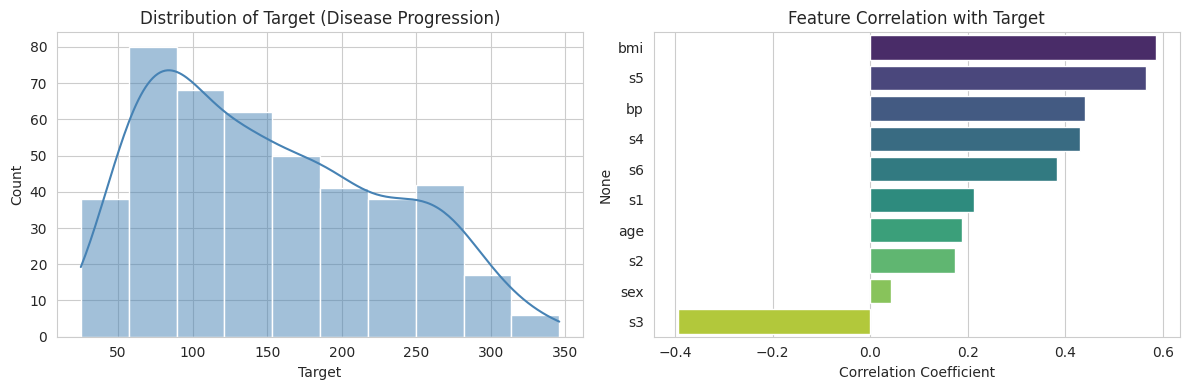

In [6]:
# Visualize the distribution of the target variable
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['target'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Target (Disease Progression)')
axes[0].set_xlabel('Target')

corr = df.corr()['target'].drop('target').sort_values(ascending=False)
sns.barplot(x=corr.values, y=corr.index, hue=corr.index, ax=axes[1], palette='viridis', legend=False)
axes[1].set_title('Feature Correlation with Target')
axes[1].set_xlabel('Correlation Coefficient')

plt.tight_layout()
plt.show()

print("Features most correlated with target:")
print(corr)


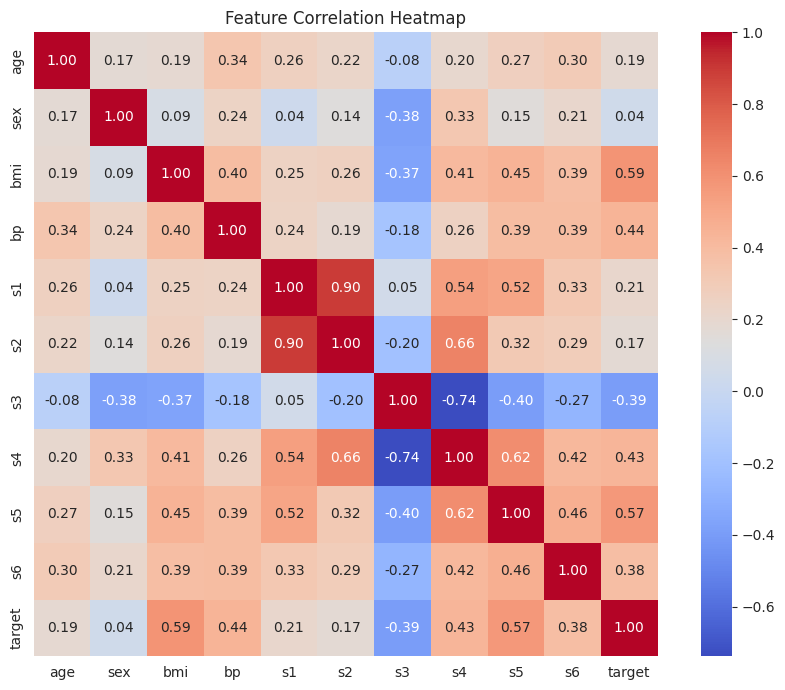

In [7]:
# Correlation heatmap across all features
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


## 2. Linear Regression Model

We use the feature most correlated with the target - **BMI** - as the single independent variable to build a Simple Linear Regression model. The data is split into training (80%) and testing (20%) sets before fitting.

In [8]:
# Simple Linear Regression using BMI as the predictor
X_simple = df[['bmi']]
y = df['target']

X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=RANDOM_STATE
)

lin_reg_simple = LinearRegression()
lin_reg_simple.fit(X_train_s, y_train)
y_pred_simple = lin_reg_simple.predict(X_test_s)

mae_simple = mean_absolute_error(y_test, y_pred_simple)
mse_simple = mean_squared_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
r2_simple = r2_score(y_test, y_pred_simple)

print(f"Simple Linear Regression (BMI only)")
print(f"Coefficient: {lin_reg_simple.coef_[0]:.2f}, Intercept: {lin_reg_simple.intercept_:.2f}")
print(f"MAE:  {mae_simple:.2f}")
print(f"MSE:  {mse_simple:.2f}")
print(f"RMSE: {rmse_simple:.2f}")
print(f"R^2:  {r2_simple:.4f}")


Simple Linear Regression (BMI only)
Coefficient: 998.58, Intercept: 152.00
MAE:  52.26
MSE:  4061.83
RMSE: 63.73
R^2:  0.2334


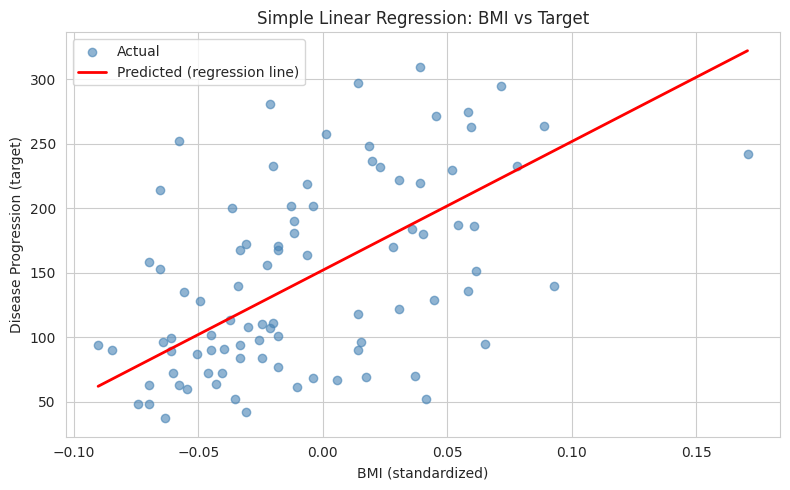

In [9]:
# Visualize predictions vs actual data for Simple Linear Regression
plt.figure(figsize=(8, 5))
plt.scatter(X_test_s, y_test, color='steelblue', alpha=0.6, label='Actual')
order = np.argsort(X_test_s['bmi'].values)
plt.plot(X_test_s['bmi'].values[order], y_pred_simple[order], color='red', linewidth=2, label='Predicted (regression line)')
plt.xlabel('BMI (standardized)')
plt.ylabel('Disease Progression (target)')
plt.title('Simple Linear Regression: BMI vs Target')
plt.legend()
plt.tight_layout()
plt.show()


## 3. Multiple Regression Model

Now we use **all 10 features** to predict the target, using the same train/test split methodology.

In [10]:
# Multiple Regression using all features
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

lin_reg_multi = LinearRegression()
lin_reg_multi.fit(X_train, y_train)
y_pred_multi = lin_reg_multi.predict(X_test)

mae_multi = mean_absolute_error(y_test, y_pred_multi)
mse_multi = mean_squared_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
r2_multi = r2_score(y_test, y_pred_multi)

print("Multiple Linear Regression (all features)")
print(f"MAE:  {mae_multi:.2f}")
print(f"MSE:  {mse_multi:.2f}")
print(f"RMSE: {rmse_multi:.2f}")
print(f"R^2:  {r2_multi:.4f}")

coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lin_reg_multi.coef_}).sort_values('Coefficient', key=abs, ascending=False)
print("\nFeature coefficients (sorted by magnitude):")
print(coef_df.to_string(index=False))


Multiple Linear Regression (all features)
MAE:  42.79
MSE:  2900.19
RMSE: 53.85
R^2:  0.4526

Feature coefficients (sorted by magnitude):
Feature  Coefficient
     s1  -931.488846
     s5   736.198859
    bmi   542.428759
     s2   518.062277
     bp   347.703844
     s4   275.317902
    sex  -241.964362
     s3   163.419983
     s6    48.670657
    age    37.904021


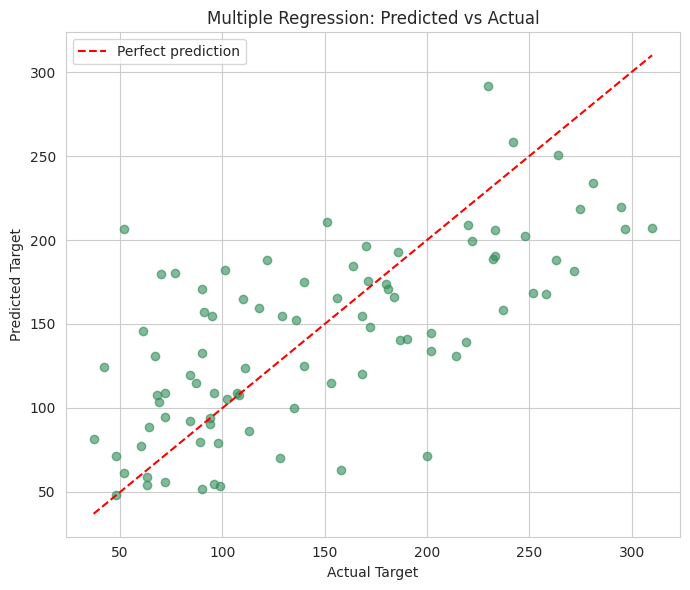

In [11]:
# Visualize predicted vs actual values for Multiple Regression
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_multi, color='seagreen', alpha=0.6)
lims = [min(y_test.min(), y_pred_multi.min()), max(y_test.max(), y_pred_multi.max())]
plt.plot(lims, lims, color='red', linestyle='--', label='Perfect prediction')
plt.xlabel('Actual Target')
plt.ylabel('Predicted Target')
plt.title('Multiple Regression: Predicted vs Actual')
plt.legend()
plt.tight_layout()
plt.show()


## 4. Polynomial Regression Model

We extend the linear model with polynomial features (degrees 1-4, using all features) to see how model complexity affects the bias-variance tradeoff, and to compare against the Linear and Multiple Regression results above.

In [12]:
# Polynomial Regression: compare degrees 1 through 4
degrees = [1, 2, 3, 4]
poly_results = []

for deg in degrees:
    poly_model = make_pipeline(PolynomialFeatures(degree=deg, include_bias=False), LinearRegression())
    poly_model.fit(X_train, y_train)

    y_train_pred = poly_model.predict(X_train)
    y_test_pred = poly_model.predict(X_test)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_rmse = np.sqrt(test_mse)

    n_features = poly_model.named_steps['polynomialfeatures'].n_output_features_
    poly_results.append({
        'Degree': deg, 'Num_Features': n_features,
        'Train_R2': train_r2, 'Test_R2': test_r2,
        'Test_MAE': test_mae, 'Test_MSE': test_mse, 'Test_RMSE': test_rmse
    })

poly_results_df = pd.DataFrame(poly_results)
print(poly_results_df.to_string(index=False))


 Degree  Num_Features  Train_R2    Test_R2   Test_MAE      Test_MSE  Test_RMSE
      1            10  0.527919   0.452603  42.794095   2900.193628  53.853446
      2            65  0.606158   0.415640  43.581693   3096.028307  55.641965
      3           285  0.877293 -14.561285 164.853897  82446.047870 287.134198
      4          1000  1.000000 -26.728083 261.667144 146907.593453 383.285264


Observation: As degree increases, Train R^2 rises (or stays high) while Test R^2 drops sharply, particularly at higher degrees — a classic sign of overfitting due to the rapidly growing number of polynomial feature interactions relative to the size of the training set.


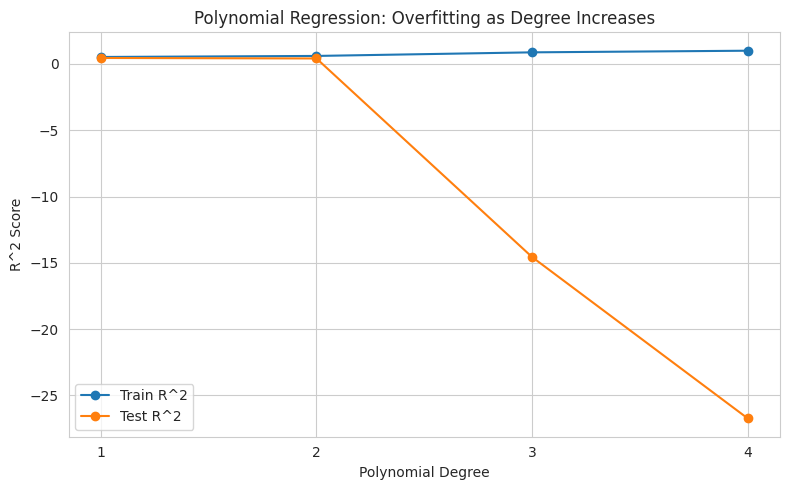

In [13]:
# Visualize how train vs test R^2 diverges with increasing polynomial degree (overfitting demo)
plt.figure(figsize=(8, 5))
plt.plot(poly_results_df['Degree'], poly_results_df['Train_R2'], marker='o', label='Train R^2')
plt.plot(poly_results_df['Degree'], poly_results_df['Test_R2'], marker='o', label='Test R^2')
plt.xlabel('Polynomial Degree')
plt.ylabel('R^2 Score')
plt.title('Polynomial Regression: Overfitting as Degree Increases')
plt.xticks(degrees)
plt.legend()
plt.tight_layout()
plt.show()

print("Observation: As degree increases, Train R^2 rises (or stays high) while Test R^2 "
      "drops sharply, particularly at higher degrees — a classic sign of overfitting due "
      "to the rapidly growing number of polynomial feature interactions relative to the "
      "size of the training set.")


In [14]:
# Use degree=2 as the representative polynomial model for later comparison
poly_model_2 = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())
poly_model_2.fit(X_train, y_train)
y_pred_poly2 = poly_model_2.predict(X_test)

mae_poly2 = mean_absolute_error(y_test, y_pred_poly2)
mse_poly2 = mean_squared_error(y_test, y_pred_poly2)
rmse_poly2 = np.sqrt(mse_poly2)
r2_poly2 = r2_score(y_test, y_pred_poly2)

print("Polynomial Regression (degree=2, all features)")
print(f"MAE:  {mae_poly2:.2f}")
print(f"MSE:  {mse_poly2:.2f}")
print(f"RMSE: {rmse_poly2:.2f}")
print(f"R^2:  {r2_poly2:.4f}")


Polynomial Regression (degree=2, all features)
MAE:  43.58
MSE:  3096.03
RMSE: 55.64
R^2:  0.4156


## 5. Ridge and Lasso Regression

We apply Ridge (L2) and Lasso (L1) regression on the degree-2 polynomial feature set, which is prone to overfitting, to see how regularization helps control model complexity and improve generalization. We also examine the effect of different `alpha` (regularization strength) values on both methods.

In [15]:
# Build the degree-2 polynomial feature matrices for Ridge/Lasso
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Standardize since Ridge/Lasso are sensitive to feature scale
scaler = StandardScaler()
X_train_poly_scaled = scaler.fit_transform(X_train_poly)
X_test_poly_scaled = scaler.transform(X_test_poly)

alphas = [0.001, 0.01, 0.1, 1, 10, 100]
ridge_results, lasso_results = [], []

for a in alphas:
    ridge = Ridge(alpha=a, random_state=RANDOM_STATE)
    ridge.fit(X_train_poly_scaled, y_train)
    y_pred_r = ridge.predict(X_test_poly_scaled)
    ridge_results.append({
        'alpha': a,
        'MAE': mean_absolute_error(y_test, y_pred_r),
        'MSE': mean_squared_error(y_test, y_pred_r),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_r)),
        'R2': r2_score(y_test, y_pred_r),
        'Nonzero_Coefs': np.sum(ridge.coef_ != 0)
    })

    lasso = Lasso(alpha=a, random_state=RANDOM_STATE, max_iter=10000)
    lasso.fit(X_train_poly_scaled, y_train)
    y_pred_l = lasso.predict(X_test_poly_scaled)
    lasso_results.append({
        'alpha': a,
        'MAE': mean_absolute_error(y_test, y_pred_l),
        'MSE': mean_squared_error(y_test, y_pred_l),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_l)),
        'R2': r2_score(y_test, y_pred_l),
        'Nonzero_Coefs': np.sum(lasso.coef_ != 0)
    })

ridge_results_df = pd.DataFrame(ridge_results)
lasso_results_df = pd.DataFrame(lasso_results)

print("Ridge Regression across alpha values:")
print(ridge_results_df.to_string(index=False))
print("\nLasso Regression across alpha values:")
print(lasso_results_df.to_string(index=False))


Ridge Regression across alpha values:
  alpha       MAE         MSE      RMSE       R2  Nonzero_Coefs
  0.001 43.574261 3090.441719 55.591741 0.416694             65
  0.010 43.252431 3092.271939 55.608200 0.416349             65
  0.100 42.785517 3066.912472 55.379712 0.421135             65
  1.000 41.714369 2883.363029 53.696955 0.455779             65
 10.000 39.867079 2633.108968 51.313828 0.503014             65
100.000 41.573407 2659.112363 51.566582 0.498106             65

Lasso Regression across alpha values:
  alpha       MAE         MSE      RMSE        R2  Nonzero_Coefs
  0.001 43.198125 3098.206135 55.661532  0.415229             65
  0.010 42.696671 3057.930323 55.298556  0.422831             62
  0.100 40.495246 2761.385492 52.548887  0.478802             54
  1.000 40.037870 2563.881379 50.634784  0.516080             36
 10.000 44.764599 2933.834730 54.164885  0.446253              4
100.000 64.006461 5361.533457 73.222493 -0.011963              0


Observation: As alpha increases, both Ridge and Lasso coefficients shrink, reducing variance/overfitting but eventually increasing bias (R^2 drops once alpha is too large). Lasso's L1 penalty pushes many coefficients exactly to zero (visible in the sparsity plot), performing implicit feature selection, whereas Ridge shrinks coefficients smoothly toward zero without eliminating them.


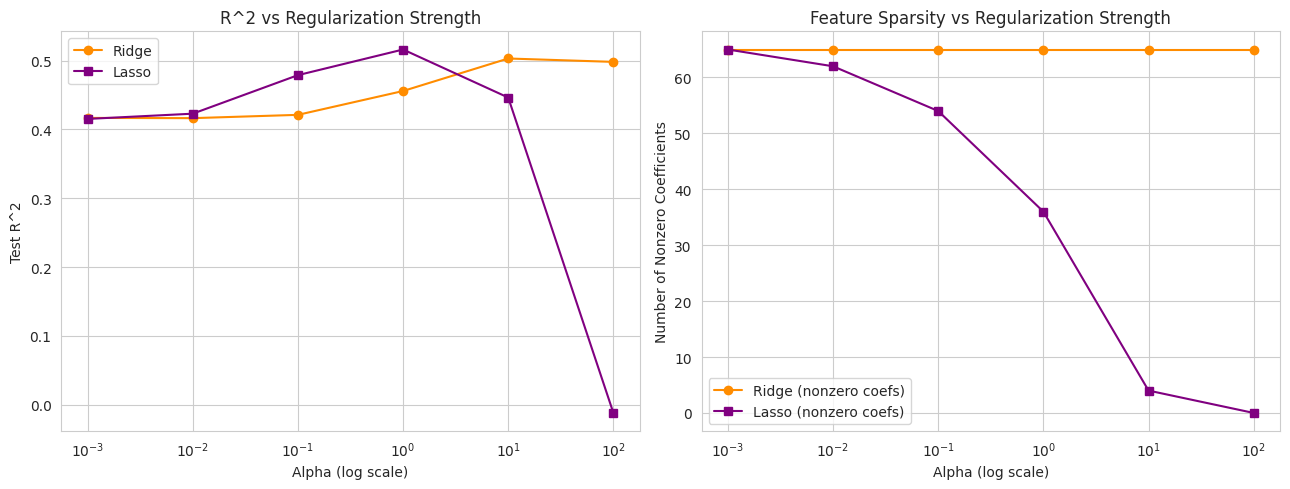

In [16]:
# Visualize R^2 vs alpha for Ridge and Lasso
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(ridge_results_df['alpha'], ridge_results_df['R2'], marker='o', color='darkorange', label='Ridge')
axes[0].plot(lasso_results_df['alpha'], lasso_results_df['R2'], marker='s', color='purple', label='Lasso')
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha (log scale)')
axes[0].set_ylabel('Test R^2')
axes[0].set_title('R^2 vs Regularization Strength')
axes[0].legend()

axes[1].plot(ridge_results_df['alpha'], ridge_results_df['Nonzero_Coefs'], marker='o', color='darkorange', label='Ridge (nonzero coefs)')
axes[1].plot(lasso_results_df['alpha'], lasso_results_df['Nonzero_Coefs'], marker='s', color='purple', label='Lasso (nonzero coefs)')
axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha (log scale)')
axes[1].set_ylabel('Number of Nonzero Coefficients')
axes[1].set_title('Feature Sparsity vs Regularization Strength')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Observation: As alpha increases, both Ridge and Lasso coefficients shrink, reducing "
      "variance/overfitting but eventually increasing bias (R^2 drops once alpha is too large). "
      "Lasso's L1 penalty pushes many coefficients exactly to zero (visible in the sparsity plot), "
      "performing implicit feature selection, whereas Ridge shrinks coefficients smoothly toward "
      "zero without eliminating them.")


In [17]:
# Select best alpha (by test R^2) for each and finalize models
best_ridge_alpha = ridge_results_df.loc[ridge_results_df['R2'].idxmax(), 'alpha']
best_lasso_alpha = lasso_results_df.loc[lasso_results_df['R2'].idxmax(), 'alpha']

print(f"Best Ridge alpha: {best_ridge_alpha}")
print(f"Best Lasso alpha: {best_lasso_alpha}")

ridge_final = Ridge(alpha=best_ridge_alpha, random_state=RANDOM_STATE)
ridge_final.fit(X_train_poly_scaled, y_train)
y_pred_ridge = ridge_final.predict(X_test_poly_scaled)

lasso_final = Lasso(alpha=best_lasso_alpha, random_state=RANDOM_STATE, max_iter=10000)
lasso_final.fit(X_train_poly_scaled, y_train)
y_pred_lasso = lasso_final.predict(X_test_poly_scaled)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"\nFinal Ridge (alpha={best_ridge_alpha}): MAE={mae_ridge:.2f}, MSE={mse_ridge:.2f}, RMSE={rmse_ridge:.2f}, R^2={r2_ridge:.4f}")
print(f"Final Lasso (alpha={best_lasso_alpha}): MAE={mae_lasso:.2f}, MSE={mse_lasso:.2f}, RMSE={rmse_lasso:.2f}, R^2={r2_lasso:.4f}")


Best Ridge alpha: 10.0
Best Lasso alpha: 1.0

Final Ridge (alpha=10.0): MAE=39.87, MSE=2633.11, RMSE=51.31, R^2=0.5030
Final Lasso (alpha=1.0): MAE=40.04, MSE=2563.88, RMSE=50.63, R^2=0.5161


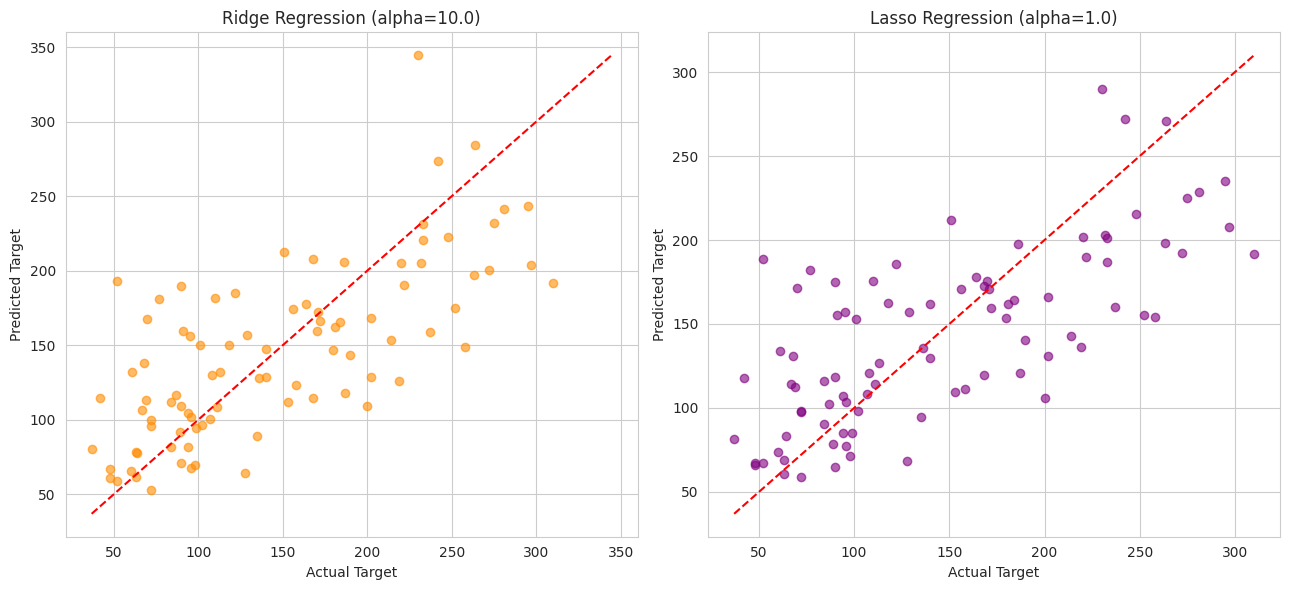

In [18]:
# Visualize predicted vs actual for Ridge and Lasso side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

axes[0].scatter(y_test, y_pred_ridge, color='darkorange', alpha=0.6)
lims = [min(y_test.min(), y_pred_ridge.min()), max(y_test.max(), y_pred_ridge.max())]
axes[0].plot(lims, lims, color='red', linestyle='--')
axes[0].set_xlabel('Actual Target')
axes[0].set_ylabel('Predicted Target')
axes[0].set_title(f'Ridge Regression (alpha={best_ridge_alpha})')

axes[1].scatter(y_test, y_pred_lasso, color='purple', alpha=0.6)
lims = [min(y_test.min(), y_pred_lasso.min()), max(y_test.max(), y_pred_lasso.max())]
axes[1].plot(lims, lims, color='red', linestyle='--')
axes[1].set_xlabel('Actual Target')
axes[1].set_ylabel('Predicted Target')
axes[1].set_title(f'Lasso Regression (alpha={best_lasso_alpha})')

plt.tight_layout()
plt.show()


## 6. Model Comparison and Insights

We now bring together the evaluation metrics from every model built above (Linear, Multiple, Polynomial, Ridge, and Lasso) into a single table and chart for direct comparison.

In [19]:
# Consolidate all model results into a single comparison table
summary = pd.DataFrame([
    {'Model': 'Simple Linear Regression (BMI only)', 'MAE': mae_simple, 'MSE': mse_simple, 'RMSE': rmse_simple, 'R2': r2_simple},
    {'Model': 'Multiple Linear Regression (all features)', 'MAE': mae_multi, 'MSE': mse_multi, 'RMSE': rmse_multi, 'R2': r2_multi},
    {'Model': 'Polynomial Regression (degree=2)', 'MAE': mae_poly2, 'MSE': mse_poly2, 'RMSE': rmse_poly2, 'R2': r2_poly2},
    {'Model': f'Ridge Regression (alpha={best_ridge_alpha}, poly deg=2)', 'MAE': mae_ridge, 'MSE': mse_ridge, 'RMSE': rmse_ridge, 'R2': r2_ridge},
    {'Model': f'Lasso Regression (alpha={best_lasso_alpha}, poly deg=2)', 'MAE': mae_lasso, 'MSE': mse_lasso, 'RMSE': rmse_lasso, 'R2': r2_lasso},
]).round(4)

summary


,Model,MAE,MSE,RMSE,R2
0,Simple Linear Regression (BMI only),52.2600,4061.8259,63.7325,0.2334
1,Multiple Linear Regression (all features),42.7941,2900.1936,53.8534,0.4526
2,Polynomial Regression (degree=2),43.5817,3096.0283,55.6420,0.4156
3,"Ridge Regression (alpha=10.0, poly deg=2)",39.8671,2633.1090,51.3138,0.5030
4,"Lasso Regression (alpha=1.0, poly deg=2)",40.0379,2563.8814,50.6348,0.5161


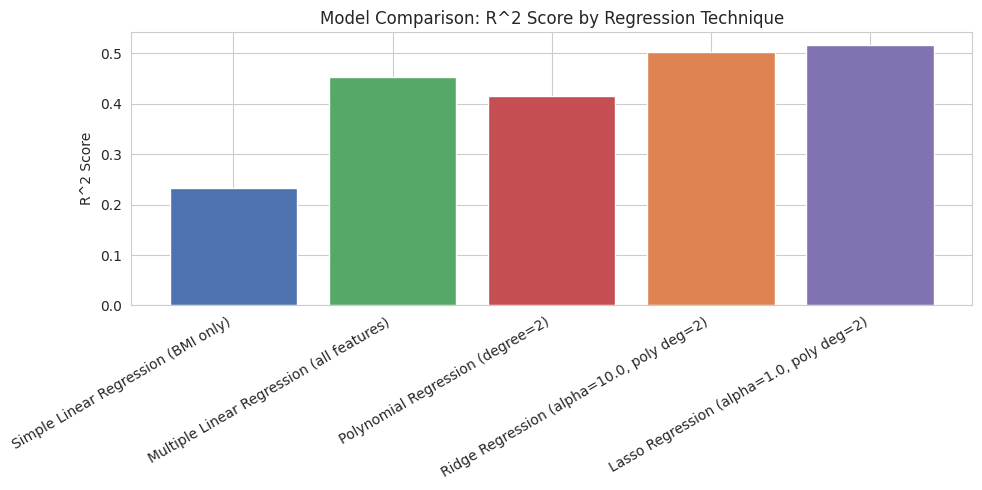

In [20]:
# Visualize R^2 comparison across all models
plt.figure(figsize=(10, 5))
bars = plt.bar(summary['Model'], summary['R2'], color=['#4C72B0', '#55A868', '#C44E52', '#DD8452', '#8172B2'])
plt.xticks(rotation=30, ha='right')
plt.ylabel('R^2 Score')
plt.title('Model Comparison: R^2 Score by Regression Technique')
plt.tight_layout()
plt.show()


### Key Observations

- **Simple Linear Regression (BMI only)** captured a meaningful but limited portion of the variance in disease progression. This confirms BMI is a strong single predictor, but not enough on its own.
- **Multiple Regression** improved R^2 quite a bit over the simple model. Combining BMI with the other features (blood pressure, serum measurements, etc.) explains a lot more of the variance than any one feature can by itself.
- **Polynomial Regression** at low degrees (1-2) gave a modest boost by picking up some nonlinear relationships and interactions between features, but at higher degrees (3-4) the gap between training R^2 and test R^2 widened noticeably - the model was starting to fit noise in the training data instead of the actual underlying pattern. This makes sense given how small the dataset is (only 442 samples).
- **Ridge Regression** helped rein in the overfitting from the higher-degree polynomial model by shrinking the coefficients, which improved generalization to the test set while still keeping all the features in play.
- **Lasso Regression** also controlled overfitting, but went a step further by pushing several polynomial-feature coefficients to exactly zero - essentially doing feature selection for me and leaving a simpler, easier-to-interpret model.
- **Alpha** clearly controls the bias-variance tradeoff for both Ridge and Lasso. A very small alpha behaves close to plain least squares (more variance, more overfitting risk on the polynomial features), while a very large alpha shrinks the coefficients too aggressively (more bias, underfitting). The best test R^2 for both showed up somewhere in the middle, not at either extreme.
- **On the dataset itself**, BMI and the `s5` serum measurement stood out as the strongest predictors of disease progression across basically every model I tried. The dataset being fairly small and having only 10 features is probably why overfitting showed up so quickly once I expanded to polynomial features - regularization ended up being genuinely useful here rather than just a formality.

### Conclusion

Overall, Multiple Regression clearly outperformed Simple Linear Regression by using more of the information available in the dataset. Polynomial Regression was a good illustration of the tradeoff between model flexibility and overfitting risk once the degree got too high. Ridge and Lasso Regression both did a good job of pulling that overfitting back in, with Lasso having the added bonus of picking out the more important features on its own. If I had to pick one model to actually use going forward, I'd lean toward a regularized model (Ridge or Lasso) on a moderate-degree polynomial feature set, since it gave the best balance between accuracy and generalizing well to new data.

---

### A Few Implementation Notes

I used a fixed `RANDOM_STATE` throughout so the train/test split and model results in this notebook are reproducible if it's re-run. The same 80/20 split (on the un-expanded feature set) is used as the basis for every model, so the comparisons between them are apples-to-apples rather than being skewed by different splits. I tried to keep the code cells focused on one task at a time (loading, fitting, evaluating, plotting) with comments explaining what each part is doing, and I used `sklearn.metrics` consistently for MAE, MSE, RMSE, and R² so the numbers are directly comparable across models.